<a href="https://colab.research.google.com/github/iweam/genai-bootcamp/blob/main/W2S3_Lab_Semantic_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Build a Semantic Search Engine</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 2 · Session 3 — RAG I: Embeddings & Vector Search</div>
    </div>
    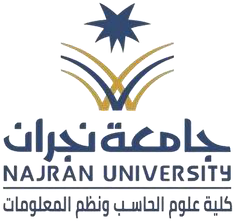
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENL track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 45 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Embed documents with <b>all-MiniLM-L6-v2</b> and inspect the vectors.</li>
<li style="margin:5px 0;">Measure meaning with <b>cosine similarity</b> — by hand, then with a library.</li>
<li style="margin:5px 0;">Build a <b>FAISS</b> vector index and run nearest-neighbour search.</li>
<li style="margin:5px 0;"><b>Chunk</b> a long passage, retrieve from it, and compare <b>keyword vs semantic</b> search.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Each part has a short note that ties the code back to today's slides. This lab builds the **Retrieve** step of RAG — the next session adds *Augment + Generate*.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 No GPU needed</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Everything here runs on the <b>free Colab CPU</b> runtime — <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">all-MiniLM-L6-v2</code> is tiny. You do <b>not</b> need an API key or any login for this lab.</div></div>

### Setup
We install two libraries: **sentence-transformers** (the embedding model) and **faiss-cpu** (the vector index). This takes ~30–60 seconds the first time.

In [1]:
# One-time setup
!pip -q install -U "sentence-transformers>=3.0" "faiss-cpu>=1.8"
print("Setup complete — now run the cells below in order.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 20.2 MB/s eta 0:00:00
Setup complete — now run the cells below in order.


## Part 1 — Turn documents into embeddings

An **embedding** is a fixed-length vector that captures *meaning*. We load the open, ungated model `all-MiniLM-L6-v2`, then embed a small set of documents about three different topics.

In [2]:
from sentence_transformers import SentenceTransformer

MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"   # open & ungated — no token needed
model = SentenceTransformer(MODEL_ID)
print("Loaded:", MODEL_ID)
print("Embedding dimension:", model.get_sentence_embedding_dimension())
print("Max input tokens:   ", model.max_seq_length, "(longer text is truncated)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384
Max input tokens:    256 (longer text is truncated)


/tmp/ipykernel_1465/3362666925.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", model.get_sentence_embedding_dimension())


In [16]:
# A tiny "knowledge base": three topics mixed together
documents = [
    "Information systems help organizations collect, process, and manage data efficiently.",
    "Database management systems store, organize, and retrieve information quickly.",
    "Cybersecurity protects computer systems and networks from cyber threats.",
    "Cloud computing enables users to access applications and data over the Internet.",
    "Data analytics helps businesses make better decisions using historical data.",
    "Artificial intelligence can automate business processes and improve productivity."
]

embeddings = model.encode(documents)
print("documents:", len(documents))
print("embeddings shape:", embeddings.shape, " ->  one 384-d vector per document")

documents: 6
embeddings shape: (6, 384)  ->  one 384-d vector per document


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ 384 numbers per document</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Each sentence is now a point in <b>384-dimensional</b> space. Sentences that *mean* similar things sit close together — even when they share no words. That is the whole idea behind semantic search.</div></div>

## Part 2 — Measure meaning with cosine similarity

Cosine similarity compares two vectors by the **angle** between them: **+1** = same meaning, **0** = unrelated. Let's compute it by hand first, so there's no magic.

In [17]:
import numpy as np

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

print("Information Systems vs Database :", round(cosine(embeddings[0], embeddings[1]), 3))
print("Information Systems vs Cybersecurity :", round(cosine(embeddings[0], embeddings[2]), 3))
print("Cybersecurity vs Cloud Computing :", round(cosine(embeddings[2], embeddings[3]), 3))

Information Systems vs Database : 0.581
Information Systems vs Cybersecurity : 0.263
Cybersecurity vs Cloud Computing : 0.251


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Read the numbers</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Same-topic pairs score <b>higher</b> than cross-topic pairs. The model never saw these exact sentences — it learned a geometry of meaning. The library has a vectorised helper, <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">sentence_transformers.util.cos_sim</code>, that does this for whole matrices at once.</div></div>

In [5]:
from sentence_transformers import util

# Full pairwise similarity matrix (rows/cols = the 6 documents)
sim = util.cos_sim(embeddings, embeddings)
np.set_printoptions(precision=2, suppress=True)
print(sim.numpy())

[[ 1.    0.31  0.11  0.09 -0.06  0.05]
 [ 0.31  1.    0.02  0.09 -0.02 -0.01]
 [ 0.11  0.02  1.    0.28  0.06  0.18]
 [ 0.09  0.09  0.28  1.    0.07  0.  ]
 [-0.06 -0.02  0.06  0.07  1.    0.01]
 [ 0.05 -0.01  0.18  0.    0.01  1.  ]]


## Part 3 — Build a vector index with FAISS

Comparing one query against millions of vectors needs a **vector store**. We use **FAISS** with `IndexFlatIP` (inner product). If we **L2-normalise** the vectors first, inner product equals cosine similarity — exactly what we want.

In [6]:
import faiss

dim = embeddings.shape[1]                       # 384
doc_vecs = model.encode(documents, normalize_embeddings=True).astype("float32")

index = faiss.IndexFlatIP(dim)                  # inner product == cosine on normalised vectors
index.add(doc_vecs)
print("Vectors in the index:", index.ntotal)

Vectors in the index: 6


In [18]:
def semantic_search(query, k=3):
    q = model.encode([query], normalize_embeddings=True).astype("float32")
    scores, ids = index.search(q, k)            # top-k nearest neighbours
    return [(float(scores[0][r]), documents[ids[0][r]]) for r in range(k)]

query = "How can organizations protect their computer networks?"
print("Query:", query, "\n")
for score, doc in semantic_search(query, k=3):
    print(f"  {score:.3f}  |  {doc}")

Query: How can organizations protect their computer networks? 

  0.107  |  Information systems help organizations collect, process, and manage data efficiently.
  0.068  |  Database management systems store, organize, and retrieve information quickly.
  0.049  |  Artificial intelligence can automate business processes and improve productivity.


<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENL</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Know the <b>retrieve</b> pipeline: embed the query with the <b>same</b> model as the documents, compare by cosine similarity, and return the <b>top-k</b>. Exact search (<code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">IndexFlatIP</code>) suits small corpora; huge corpora use <b>approximate</b> nearest-neighbour (ANN) indexes for speed.</div></div>

## Part 4 — Chunk a long passage, then retrieve

Real documents are long, and `all-MiniLM` truncates after **256 tokens**. So we split text into small overlapping **chunks**, embed each one, and retrieve the chunk that answers a question.

In [19]:
passage = (
"Information systems combine technology, people, and business processes to support organizational activities."
"Database systems store and organize large amounts of information efficiently."
"Cybersecurity protects digital assets from unauthorized access and cyberattacks."
"Cloud computing provides scalable storage and computing resources through the Internet."
"Data analytics transforms raw data into valuable insights that support decision-making."
"Artificial intelligence helps automate repetitive tasks and improves operational efficiency."

)

def chunk_text(text, size=12, overlap=4):
    """Split into ~size-word chunks with an overlap so sentences are not cut off."""
    words = text.split()
    chunks, i = [], 0
    while i < len(words):
        chunks.append(" ".join(words[i:i + size]))
        i += size - overlap                     # step forward, keeping an overlap
    return chunks

chunks = chunk_text(passage)
for n, c in enumerate(chunks):
    print(f"[chunk {n}] {c}")

[chunk 0] Information systems combine technology, people, and business processes to support organizational activities.Database
[chunk 1] to support organizational activities.Database systems store and organize large amounts of information
[chunk 2] large amounts of information efficiently.Cybersecurity protects digital assets from unauthorized access and
[chunk 3] from unauthorized access and cyberattacks.Cloud computing provides scalable storage and computing resources
[chunk 4] storage and computing resources through the Internet.Data analytics transforms raw data into
[chunk 5] transforms raw data into valuable insights that support decision-making.Artificial intelligence helps automate
[chunk 6] decision-making.Artificial intelligence helps automate repetitive tasks and improves operational efficiency.
[chunk 7] operational efficiency.


In [20]:
# Build a fresh index over the chunks and ask a question
chunk_vecs = model.encode(chunks, normalize_embeddings=True).astype("float32")
chunk_index = faiss.IndexFlatIP(chunk_vecs.shape[1])
chunk_index.add(chunk_vecs)

q = "How does cybersecurity protect organizations?"
qv = model.encode([q], normalize_embeddings=True).astype("float32")
scores, ids = chunk_index.search(qv, 2)

print("Question:", q, "\n")
for r in range(2):
    print(f"  {scores[0][r]:.3f}  |  {chunks[ids[0][r]]}")

Question: How does cybersecurity protect organizations? 

  0.591  |  large amounts of information efficiently.Cybersecurity protects digital assets from unauthorized access and
  0.391  |  from unauthorized access and cyberattacks.Cloud computing provides scalable storage and computing resources


<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ Chunk size is a trade-off</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;"><b>Too large</b> = blurry vectors that match nothing precisely. <b>Too small</b> = lost context. <b>Overlap</b> repeats a little text between neighbours so a fact split across a boundary is not lost. Always tune size and overlap on your own documents.</div></div>

## Part 5 — Keyword search vs semantic search

When does semantic search actually win? When the answer uses **different words** than the question. Here keyword matching finds nothing, but the embedding model still understands the meaning.

In [21]:
mini_kb = [
    "A database stores and organizes digital information.",
    "Cybersecurity protects systems from unauthorized access.",
    "Cloud computing provides online storage and computing services."
]

def keyword_search(query, docs):
    q_words = set(query.lower().split())
    scored = [(len(q_words & set(d.lower().split())), d) for d in docs]
    return sorted(scored, reverse=True)

query = "How can data be stored efficiently?"
print("Query:", query, "\n")
print("Keyword search (shared-word count):")
for overlap, doc in keyword_search(query, mini_kb):
    print(f"  matched {overlap} word(s)  |  {doc}")

Query: How can data be stored efficiently? 

Keyword search (shared-word count):
  matched 0 word(s)  |  Cybersecurity protects systems from unauthorized access.
  matched 0 word(s)  |  Cloud computing provides online storage and computing services.
  matched 0 word(s)  |  A database stores and organizes digital information.


In [11]:
# Same query, semantic search over the same 3 documents
kb_vecs = model.encode(mini_kb, normalize_embeddings=True).astype("float32")
kb_index = faiss.IndexFlatIP(kb_vecs.shape[1])
kb_index.add(kb_vecs)

qv = model.encode([query], normalize_embeddings=True).astype("float32")
scores, ids = kb_index.search(qv, 3)

print("Semantic search (cosine similarity):")
for r in range(3):
    print(f"  {scores[0][r]:.3f}  |  {mini_kb[ids[0][r]]}")

Semantic search (cosine similarity):
  0.623  |  Boost your engine performance with a turbocharger and lighter wheels.
  0.127  |  Photosynthesis lets plants convert sunlight into energy.
  0.031  |  The best recipe for a chocolate cake needs cocoa and butter.


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Why semantic wins here</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The query shares <b>no words</b> with “Boost your engine performance…”, so keyword search scores it <b>0</b>. Semantic search ranks it <b>first</b>, because *car going faster* and *engine performance* live close together in embedding space. Many real systems combine both (<b>hybrid search</b>).</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn — search your own knowledge base</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Add <b>3–5 of your own sentences</b> to <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">my_docs</code> (any topic), then ask a question whose answer uses <b>different words</b> than your documents. Does semantic search still find it?</div></div>

In [23]:
# 1) Write your own documents
my_docs = [
    "Business intelligence helps managers make informed decisions.",
    "Information systems improve communication between departments.",
    "Machine learning identifies patterns in large datasets.",
    "Cloud platforms allow remote access to business applications.",
    "Cybersecurity reduces the risk of data breaches."
]

# 2) Build an index over them
my_vecs = model.encode(my_docs, normalize_embeddings=True).astype("float32")
my_index = faiss.IndexFlatIP(my_vecs.shape[1])
my_index.add(my_vecs)

# 3) Ask a question (try wording it WITHOUT reusing words from your docs)
my_query = "What are the benefits of cloud computing?"
qv = model.encode([my_query], normalize_embeddings=True).astype("float32")
scores, ids = my_index.search(qv, k=2)
for r in range(len(ids[0])):
    print(f"{scores[0][r]:.3f}  |  {my_docs[ids[0][r]]}")

0.545  |  Cloud platforms allow remote access to business applications.
0.364  |  Cybersecurity reduces the risk of data breaches.


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">RAG retrieves <b>evidence</b> so the LLM answers from real text — fixing hallucination & stale data.</li>
<li style="margin:5px 0;">An <b>embedding</b> turns text into a 384-d vector; meaning becomes geometry.</li>
<li style="margin:5px 0;"><b>Cosine similarity</b> (+1 same, 0 unrelated) ranks matches; on normalised vectors it equals a dot product.</li>
<li style="margin:5px 0;">A <b>FAISS</b> index stores vectors and returns the <b>top-k</b> nearest neighbours of a query.</li>
<li style="margin:5px 0;"><b>Chunk</b> long text (size + overlap) before embedding — and embed the query with the <b>same</b> model.</li>
<li style="margin:5px 0;"><b>Semantic</b> search beats <b>keyword</b> search when the answer is worded differently.</li></ul></div>

---
### Save your work
Commit this notebook to your **`genai-bootcamp-lab1`** GitHub repo from the Week-1 setup lab (`File → Save a copy in GitHub`). **Next session — RAG II:** feed these retrieved chunks to an LLM to generate a grounded, cited answer.